In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# all required libraries are installed

In [31]:
data=pd.read_csv("battery.csv")
data.head(10)
# data.isna().sum()
# data.duplicated().sum()
# since the is already cleaned we will move to eda

,Battery Age,Daily Usage Hours,Gaming User,Design Capacity,Cycle Count,CPU Usage,GPU Usage,Power Consumption,Average Temperature,Full Charge Capacity,Battery Health
0,5,9.797617,0,57884,1267,64.587764,43.887115,84.366245,35.645636,44961.935220,76.923383
1,9,7.101557,0,63824,1500,45.542182,36.534144,80.629042,31.782432,46619.665590,73.496153
2,9,10.085255,0,79414,1500,64.640516,52.238349,87.853504,32.122879,63343.419989,81.514041
3,5,7.946047,0,61142,1153,55.095724,30.535647,69.686012,30.371133,50407.438833,79.742100
4,7,9.628460,0,50956,1500,60.145756,36.749489,64.734123,27.536232,34757.377982,67.882552
5,7,7.584193,0,58928,1500,56.556801,37.835722,79.712851,32.096544,43334.547962,70.980071
6,8,5.555552,1,54721,1500,67.622296,73.197305,83.960476,34.940727,37844.844854,69.580059
7,7,11.537404,0,56157,1500,83.142065,60.329310,116.212847,34.605075,40967.426951,74.850306
8,1,6.952252,0,51696,161,54.529712,33.191792,76.280107,28.872215,50087.394430,96.916534
9,9,7.655985,0,72862,1500,55.023629,41.232222,95.948667,29.625280,55898.829903,75.864935


In [32]:
data.describe()

,Battery Age,Daily Usage Hours,Gaming User,Design Capacity,Cycle Count,CPU Usage,GPU Usage,Power Consumption,Average Temperature,Full Charge Capacity,Battery Health
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,4.571667,6.435078,0.102500,62049.919167,993.813333,50.047021,37.081954,68.510005,30.483731,51798.125944,82.944518
std,2.831939,3.149664,0.303431,10096.807179,527.254899,18.859965,17.485642,21.213489,2.624044,11598.140456,9.924455
min,0.000000,1.002497,0.000000,45002.000000,0.000000,9.151884,5.000000,20.133013,22.908857,28181.020459,59.840266
25%,2.000000,3.722104,0.000000,53583.250000,530.500000,34.223028,24.084790,52.238214,28.758142,42865.372454,75.315849
50%,5.000000,6.322145,0.000000,61888.000000,1188.000000,50.097711,34.979134,67.399336,30.398357,51698.379658,81.461246
75%,7.000000,9.162563,0.000000,70734.750000,1500.000000,64.294947,46.615097,82.529511,32.231464,60403.354634,91.414773
max,9.000000,11.986722,1.000000,79959.000000,1500.000000,100.000000,98.339932,137.154936,39.934239,79263.000000,100.000000


In [33]:
len(data)

1200

array([[<Axes: title={'center': 'Battery Age'}>,
        <Axes: title={'center': 'Daily Usage Hours'}>,
        <Axes: title={'center': 'Gaming User'}>],
       [<Axes: title={'center': 'Design Capacity'}>,
        <Axes: title={'center': 'Cycle Count'}>,
        <Axes: title={'center': 'CPU Usage'}>],
       [<Axes: title={'center': 'GPU Usage'}>,
        <Axes: title={'center': 'Power Consumption'}>,
        <Axes: title={'center': 'Average Temperature'}>],
       [<Axes: title={'center': 'Full Charge Capacity'}>,
        <Axes: title={'center': 'Battery Health'}>, <Axes: >]],
      dtype=object)

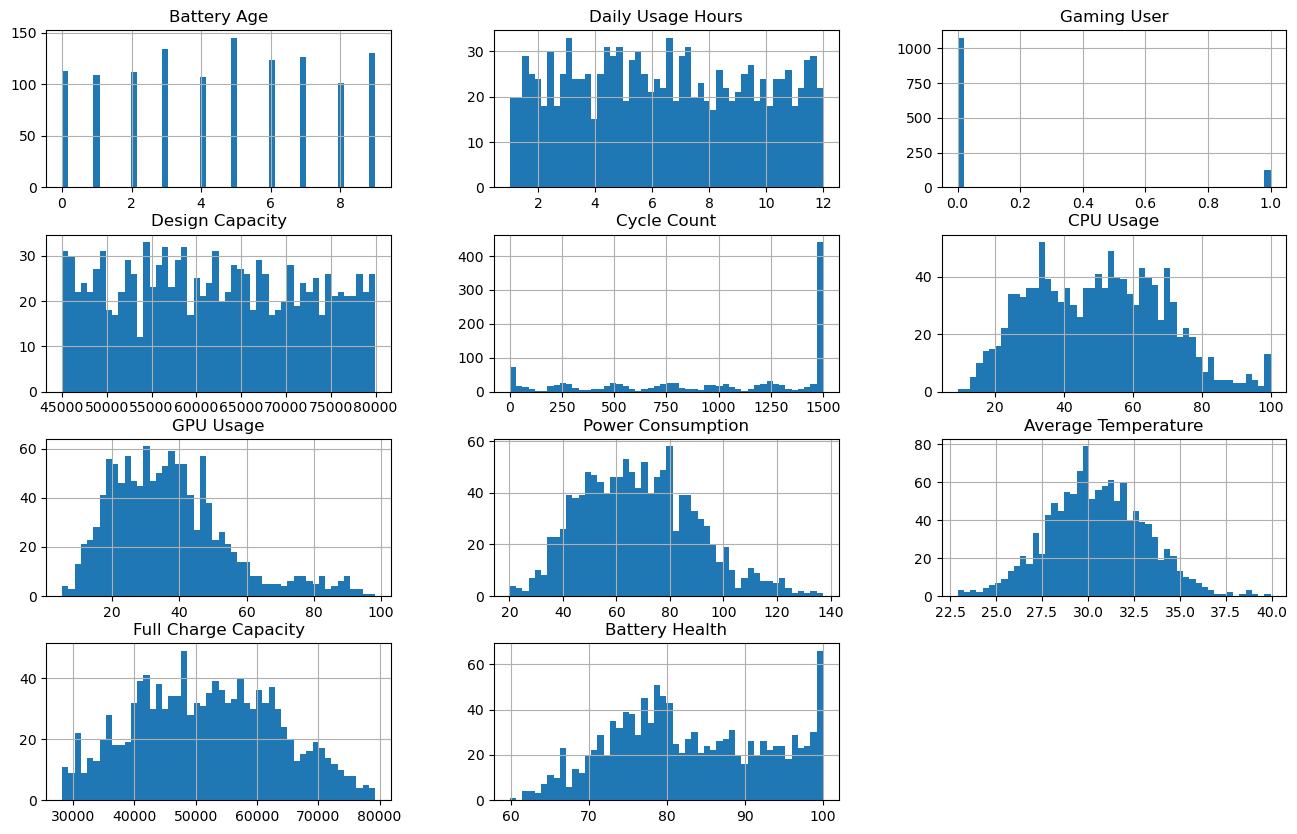

In [34]:
data.hist(bins=50,figsize=(16,10))

In [35]:
data1=data.head(1800)
data1=data1.to_csv("bat_train.csv")
data2=data.tail(200)
data2=data2.to_csv("bat_test.csv")
# in this way we have created test and train datasets

In [36]:
# now we will train our model
data1=pd.read_csv("bat_train.csv")
X = data1[[
    "Battery Age", 
    "Daily Usage Hours", 
    "Gaming User", 
    "Design Capacity", 
    "Cycle Count", 
    "CPU Usage", 
    "GPU Usage", 
    "Power Consumption", 
    "Average Temperature", 
    "Full Charge Capacity"
]]

Y = data1["Battery Health"]
X1=pd.get_dummies(X)
model = RandomForestRegressor(random_state=42)
model.fit(X1.values,Y.values)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [37]:
# now testing
data2=pd.read_csv("bat_test.csv")
X1_test=data2[[
    "Battery Age", 
    "Daily Usage Hours", 
    "Gaming User", 
    "Design Capacity", 
    "Cycle Count", 
    "CPU Usage", 
    "GPU Usage", 
    "Power Consumption", 
    "Average Temperature", 
    "Full Charge Capacity"
]]
y_test=data2["Battery Health"]
X1_test_encoded=pd.get_dummies(X1_test)
X_test_encoded = X1_test_encoded.reindex(
    columns=X1_test_encoded.columns,
    fill_value=0
)

In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
#prediction
predictions = model.predict(X_test_encoded.values)


# Evaluation
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²:   {r2:.4f}")
mape = np.mean(np.abs((y_test - predictions) / y_test)) * 100
regression_accuracy = 100 - mape
print(f"Mean Absolute Percentage Error: {mape:.2f}%")
print(f"Model Regression Accuracy: {regression_accuracy:.2f}%")

MAE:  0.53
RMSE: 0.69
R²:   0.9948
Mean Absolute Percentage Error: 0.65%
Model Regression Accuracy: 99.35%
